# STEP 1 — Install Required Libraries

In [1]:
!pip -q install kagglehub segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


# STEP 2 — Imports and Reproducibility Setup

In [2]:
import os
import gc
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU not available. Enable a T4 GPU before continuing.")


Device: cuda
GPU: Tesla T4


# STEP 3 — Record Environment Versions

In [3]:
import albumentations
import segmentation_models_pytorch

environment_versions = {
    "pytorch": torch.__version__,
    "albumentations": albumentations.__version__,
    "segmentation_models_pytorch": segmentation_models_pytorch.__version__,
    "opencv": cv2.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}

for key, value in environment_versions.items():
    print(f"{key}: {value}")


pytorch: 2.11.0+cu128
albumentations: 2.0.8
segmentation_models_pytorch: 0.5.0
opencv: 5.0.0
numpy: 2.1.3
pandas: 2.2.3


# STEP 4 — Download PlantVillage Dataset

In [4]:
import kagglehub

download_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Downloaded dataset path:")
print(download_path)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Downloaded dataset path:
/kaggle/input/plantvillage-dataset


# STEP 5 — Detect Dataset Root

In [5]:
base_path = Path(download_path)

def find_dataset_root(base):
    candidates = [base]
    candidates.extend(
        p for p in base.rglob("*")
        if p.is_dir()
    )

    required = {
        "color",
        "grayscale",
        "segmented"
    }

    for path in candidates:
        try:
            folders = {
                x.name
                for x in path.iterdir()
                if x.is_dir()
            }

            if required.issubset(folders):
                return path

        except PermissionError:
            continue

    return None

dataset_root = find_dataset_root(base_path)

print("Dataset root:", dataset_root)

assert dataset_root is not None
assert (dataset_root / "color").exists()
assert (dataset_root / "segmented").exists()

print("✅ Dataset structure found.")


Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset
✅ Dataset structure found.


# STEP 6 — Mount Google Drive

In [6]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Segmentation"
)

print("Project directory:", PROJECT_DIR)

assert PROJECT_DIR.exists(), (
    "PlantVillage_Segmentation folder not found in this Drive."
)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/PlantVillage_Segmentation


# STEP 6B — Confirm FPN Recovery Checkpoint

In [8]:
RECOVERY_CHECKPOINT = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Segmentation/"
    "experiments/FPN/checkpoints/"
    "last_fpn.pth"
)

print(
    "Recovery checkpoint:",
    RECOVERY_CHECKPOINT
)

print(
    "Exists:",
    RECOVERY_CHECKPOINT.exists()
)


if RECOVERY_CHECKPOINT.exists():

    print(
        "Size (MB):",
        RECOVERY_CHECKPOINT.stat().st_size
        / 1024**2
    )


assert RECOVERY_CHECKPOINT.exists(), (
    "STOP: last_fpn.pth was not found."
)

print(
    "✅ Recovery checkpoint confirmed."
)

Recovery checkpoint: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/checkpoints/last_fpn.pth
Exists: True
Size (MB): 265.25724506378174
✅ Recovery checkpoint confirmed.


# STEP 7 — Load Final Preprocessing Artifacts

In [9]:
FINAL_MANIFEST = (
    PROJECT_DIR /
    "final_segmentation_manifest.csv"
)

FINAL_CONFIG = (
    PROJECT_DIR /
    "segmentation_preprocessing_config.json"
)

print("Manifest exists:", FINAL_MANIFEST.exists())
print("Config exists:", FINAL_CONFIG.exists())

assert FINAL_MANIFEST.exists()
assert FINAL_CONFIG.exists()

final_df = pd.read_csv(FINAL_MANIFEST)

with open(FINAL_CONFIG, "r") as f:
    preprocessing_config = json.load(f)

print("\nTotal samples:", len(final_df))
print("\nSplit distribution:")
print(final_df["split"].value_counts())
print("\nClasses:", final_df["class"].nunique())

assert len(final_df) == 52969
assert (final_df["split"] == "train").sum() == 42371
assert (final_df["split"] == "val").sum() == 5300
assert (final_df["split"] == "test").sum() == 5298
assert final_df["class"].nunique() == 38

print("\n✅ Final manifest verified.")


Manifest exists: True
Config exists: True

Total samples: 52969

Split distribution:
split
train    42371
val       5300
test      5298
Name: count, dtype: int64

Classes: 38

✅ Final manifest verified.


# STEP 8 — Verify Final Preprocessing Configuration

In [10]:
BLACK_THRESHOLD = int(
    preprocessing_config["black_threshold"]
)

IMAGE_SIZE = int(
    preprocessing_config["input_image_size"][0]
)

print("Black threshold:", BLACK_THRESHOLD)
print("Image size:", IMAGE_SIZE)

assert BLACK_THRESHOLD == 15
assert IMAGE_SIZE == 256

print("✅ Preprocessing configuration verified.")


Black threshold: 15
Image size: 256
✅ Preprocessing configuration verified.


# STEP 9 — Verify Manifest Paths

In [11]:
sample_check = final_df.sample(
    n=10,
    random_state=SEED
)

missing_color = 0
missing_segmented = 0

for _, row in sample_check.iterrows():

    color_path = dataset_root / row["color_rel"]
    segmented_path = dataset_root / row["segmented_rel"]

    if not color_path.exists():
        missing_color += 1

    if not segmented_path.exists():
        missing_segmented += 1

print("Missing color files:", missing_color)
print("Missing segmented files:", missing_segmented)

assert missing_color == 0
assert missing_segmented == 0

print("✅ Saved relative paths work in this runtime.")


Missing color files: 0
Missing segmented files: 0
✅ Saved relative paths work in this runtime.


# STEP 10 — Final Segmentation Target Function

In [12]:
def create_final_segmentation_target(
    segmented_rgb,
    target_height,
    target_width,
    black_threshold=15
):
    """
    Create a binary leaf-segmentation target from a QC-approved
    PlantVillage segmented RGB image.

    Background = 0
    Leaf       = 1

    No standalone mask image is saved to disk.
    """

    segmented_rgb = np.asarray(
        segmented_rgb,
        dtype=np.uint8
    )

    mask = (
        np.max(segmented_rgb, axis=2)
        > black_threshold
    ).astype(np.uint8)

    if mask.shape != (
        target_height,
        target_width
    ):
        mask = cv2.resize(
            mask,
            (
                target_width,
                target_height
            ),
            interpolation=cv2.INTER_NEAREST
        )

    return mask


# STEP 11 — Define Common Data Transformations

In [13]:
train_transform = A.Compose([
    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

eval_transform = A.Compose([
    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


# STEP 12 — Create Segmentation Dataset Class

In [14]:
class PlantVillageSegmentationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        dataset_root,
        transform=None,
        black_threshold=15
    ):
        self.df = dataframe.reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.transform = transform
        self.black_threshold = black_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        color_path = (
            self.dataset_root /
            row["color_rel"]
        )

        segmented_path = (
            self.dataset_root /
            row["segmented_rel"]
        )

        image = np.array(
            Image.open(
                color_path
            ).convert("RGB")
        )

        segmented = np.array(
            Image.open(
                segmented_path
            ).convert("RGB")
        )

        mask = create_final_segmentation_target(
            segmented_rgb=segmented,
            target_height=image.shape[0],
            target_width=image.shape[1],
            black_threshold=self.black_threshold
        )

        if self.transform is not None:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        mask = mask.float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return {
            "image": image,
            "mask": mask,
            "class_name": row["class"],
            "color_rel": row["color_rel"],
            "segmented_rel": row["segmented_rel"]
        }


# STEP 13 — Create Fixed Train / Validation / Test Datasets

In [15]:
train_df = final_df[
    final_df["split"] == "train"
].copy()

val_df = final_df[
    final_df["split"] == "val"
].copy()

test_df = final_df[
    final_df["split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

train_dataset = PlantVillageSegmentationDataset(
    dataframe=train_df,
    dataset_root=dataset_root,
    transform=train_transform,
    black_threshold=BLACK_THRESHOLD
)

val_dataset = PlantVillageSegmentationDataset(
    dataframe=val_df,
    dataset_root=dataset_root,
    transform=eval_transform,
    black_threshold=BLACK_THRESHOLD
)

test_dataset = PlantVillageSegmentationDataset(
    dataframe=test_df,
    dataset_root=dataset_root,
    transform=eval_transform,
    black_threshold=BLACK_THRESHOLD
)


Train: 42371
Validation: 5300
Test: 5298


# STEP 14 — Create GPU DataLoaders

In [16]:
# If this runtime gives CUDA OOM, change only BATCH_SIZE to 8
# and rerun from this cell onward.

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Batch size: 16
Train batches: 2649
Validation batches: 332
Test batches: 332


# STEP 15 — DataLoader Sanity Check

In [17]:
batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Mask values:", torch.unique(masks))

assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert masks.shape[1:] == (1, IMAGE_SIZE, IMAGE_SIZE)

mask_values = set(
    torch.unique(masks).cpu().numpy().tolist()
)

assert mask_values.issubset({0.0, 1.0})

print("✅ DataLoader sanity check passed.")


Images: torch.Size([16, 3, 256, 256])
Masks: torch.Size([16, 1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Mask values: tensor([0., 1.])
✅ DataLoader sanity check passed.


# STEP 16 — GPU Batch Test

In [18]:
images_gpu = images.to(
    DEVICE,
    non_blocking=True
)

masks_gpu = masks.to(
    DEVICE,
    non_blocking=True
)

print("Image device:", images_gpu.device)
print("Mask device:", masks_gpu.device)

print(
    "GPU memory allocated (MB):",
    torch.cuda.memory_allocated() / 1024**2
)

assert images_gpu.device.type == "cuda"
assert masks_gpu.device.type == "cuda"

del images_gpu, masks_gpu
torch.cuda.empty_cache()

print("✅ GPU batch test passed.")


Image device: cuda:0
Mask device: cuda:0
GPU memory allocated (MB): 16.0
✅ GPU batch test passed.


# STEP 17 — Create FPN Experiment Directory

In [19]:
EXPERIMENT_NAME = "FPN"

EXPERIMENT_DIR = (
    PROJECT_DIR /
    "experiments" /
    EXPERIMENT_NAME
)

CHECKPOINT_DIR = (
    EXPERIMENT_DIR /
    "checkpoints"
)

RESULTS_DIR = (
    EXPERIMENT_DIR /
    "results"
)

PREDICTION_DIR = (
    EXPERIMENT_DIR /
    "predictions"
)

for folder in [
    EXPERIMENT_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    PREDICTION_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Experiment directory:")
print(EXPERIMENT_DIR)


Experiment directory:
/content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN


# STEP 18 — Build FPN Model

In [20]:
model = smp.FPN(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Model:", model.__class__.__name__)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: FPN
Total parameters: 23,155,393
Trainable parameters: 23,155,393


# STEP 19 — Define Loss Function

In [21]:
bce_loss = torch.nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def combined_loss(
    logits,
    targets
):
    bce = bce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return (
        0.5 * bce
        +
        0.5 * dice
    )


# STEP 20 — Define Evaluation Metrics

In [22]:
def calculate_metrics(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):
    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    tp = torch.sum(
        predictions * targets
    )

    fp = torch.sum(
        predictions * (1 - targets)
    )

    fn = torch.sum(
        (1 - predictions) * targets
    )

    tn = torch.sum(
        (1 - predictions)
        * (1 - targets)
    )

    dice = (
        (2 * tp + eps)
        /
        (2 * tp + fp + fn + eps)
    )

    iou = (
        (tp + eps)
        /
        (tp + fp + fn + eps)
    )

    precision = (
        (tp + eps)
        /
        (tp + fp + eps)
    )

    recall = (
        (tp + eps)
        /
        (tp + fn + eps)
    )

    specificity = (
        (tn + eps)
        /
        (tn + fp + eps)
    )

    accuracy = (
        (tp + tn + eps)
        /
        (
            tp + tn
            + fp + fn
            + eps
        )
    )

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "specificity": specificity.item(),
        "accuracy": accuracy.item()
    }


# STEP 21 — Define Training Configuration

In [23]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)


Learning rate: 0.0001
Weight decay: 0.0001
Max epochs: 30
Early stopping patience: 7


# STEP 22 — Save FPN Experiment Configuration

In [24]:
FPN_CONFIG = {
    "experiment_name": "FPN",
    "architecture": "FPN",
    "encoder": "resnet34",
    "encoder_weights": "imagenet",
    "input_channels": 3,
    "output_channels": 1,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "random_seed": SEED,
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "black_threshold": BLACK_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "loss": "0.5*BCEWithLogitsLoss + 0.5*DiceLoss",
    "optimizer": "AdamW",
    "scheduler": "ReduceLROnPlateau(mode=max,factor=0.5,patience=3)",
    "prediction_threshold": 0.5,
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "environment_versions": environment_versions,
}

FPN_CONFIG_PATH = (
    EXPERIMENT_DIR /
    "fpn_config.json"
)

with open(
    FPN_CONFIG_PATH,
    "w"
) as f:
    json.dump(
        FPN_CONFIG,
        f,
        indent=4
    )

print("Saved:", FPN_CONFIG_PATH)


Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/fpn_config.json


# STEP 23 — Define Training Function

In [25]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device
):
    model.train()

    running_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "specificity": 0.0,
        "accuracy": 0.0
    }

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = combined_loss(
                logits,
                masks
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        with torch.no_grad():
            metrics = calculate_metrics(
                logits,
                masks
            )

        for key in metric_sums:
            metric_sums[key] += metrics[key]

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{metrics['dice']:.4f}"
        )

    num_batches = len(loader)

    epoch_results = {
        "loss": running_loss / num_batches
    }

    for key in metric_sums:
        epoch_results[key] = (
            metric_sums[key]
            / num_batches
        )

    return epoch_results


# STEP 24 — Define Validation Function

In [26]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device
):
    model.eval()

    running_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "specificity": 0.0,
        "accuracy": 0.0
    }

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = combined_loss(
                logits,
                masks
            )

        running_loss += loss.item()

        metrics = calculate_metrics(
            logits,
            masks
        )

        for key in metric_sums:
            metric_sums[key] += metrics[key]

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{metrics['dice']:.4f}"
        )

    num_batches = len(loader)

    epoch_results = {
        "loss": running_loss / num_batches
    }

    for key in metric_sums:
        epoch_results[key] = (
            metric_sums[key]
            / num_batches
        )

    return epoch_results


# STEP 25 — Train FPN

In [27]:
BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_fpn.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_fpn.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "training_history.csv"
)


# =========================================================
# DEFAULT VALUES
# =========================================================

history = []

best_val_dice = -1.0

epochs_without_improvement = 0

start_epoch = 1


# =========================================================
# RESUME FROM LAST CHECKPOINT IF AVAILABLE
# =========================================================

if LAST_MODEL_PATH.exists():

    print("=" * 60)
    print("🔄 EXISTING FPN CHECKPOINT FOUND")
    print("=" * 60)

    resume_checkpoint = torch.load(
        LAST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False
    )


    # Restore model
    model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ]
    )


    # Restore optimizer
    optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )


    # Restore training history
    history = resume_checkpoint.get(
        "history",
        []
    )


    best_val_dice = float(
        resume_checkpoint.get(
            "best_val_dice",
            -1.0
        )
    )


    last_completed_epoch = int(
        resume_checkpoint[
            "epoch"
        ]
    )


    start_epoch = (
        last_completed_epoch + 1
    )


    # =====================================================
    # Restore scheduler
    # =====================================================

    if (
        "scheduler_state_dict"
        in resume_checkpoint
    ):

        scheduler.load_state_dict(
            resume_checkpoint[
                "scheduler_state_dict"
            ]
        )

    else:

        # Older checkpoint did not save scheduler state.
        # Reconstruct it from validation history.

        dummy_parameter = (
            torch.nn.Parameter(
                torch.tensor(
                    0.0,
                    device=DEVICE
                )
            )
        )


        dummy_optimizer = (
            torch.optim.AdamW(
                [dummy_parameter],
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )
        )


        dummy_scheduler = (
            torch.optim.lr_scheduler
            .ReduceLROnPlateau(
                dummy_optimizer,
                mode="max",
                factor=0.5,
                patience=3
            )
        )


        for record in history:

            dummy_scheduler.step(
                float(
                    record[
                        "val_dice"
                    ]
                )
            )


        scheduler.load_state_dict(
            dummy_scheduler.state_dict()
        )


        reconstructed_lr = (
            dummy_optimizer
            .param_groups[0]["lr"]
        )


        for param_group in (
            optimizer.param_groups
        ):

            param_group["lr"] = (
                reconstructed_lr
            )


    # =====================================================
    # Restore AMP scaler when available
    # =====================================================

    if (
        "scaler_state_dict"
        in resume_checkpoint
    ):

        scaler.load_state_dict(
            resume_checkpoint[
                "scaler_state_dict"
            ]
        )


    # =====================================================
    # Reconstruct early-stopping counter
    # =====================================================

    reconstructed_best = -float("inf")

    epochs_without_improvement = 0


    for record in history:

        val_dice = float(
            record[
                "val_dice"
            ]
        )


        if (
            val_dice
            >
            reconstructed_best
        ):

            reconstructed_best = (
                val_dice
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


    print(
        "Last completed epoch:",
        last_completed_epoch
    )

    print(
        "Resuming from epoch:",
        start_epoch
    )

    print(
        "Best validation Dice so far:",
        f"{best_val_dice:.6f}"
    )

    print(
        "Early-stopping counter:",
        epochs_without_improvement
    )

    print(
        "Current learning rate:",
        optimizer.param_groups[0]["lr"]
    )

    print()

    print(
        "✅ Training state restored."
    )


else:

    print(
        "No previous checkpoint found."
    )

    print(
        "Starting FPN from Epoch 1."
    )


# =========================================================
# RESUME TRAINING
# =========================================================

training_start_time = time.time()


if start_epoch <= MAX_EPOCHS:

    for epoch in range(
        start_epoch,
        MAX_EPOCHS + 1
    ):

        print(
            f"\nEpoch "
            f"{epoch}/{MAX_EPOCHS}"
        )

        print("-" * 60)


        train_results = (
            train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                scaler=scaler,
                device=DEVICE
            )
        )


        val_results = (
            validate_one_epoch(
                model=model,
                loader=val_loader,
                device=DEVICE
            )
        )


        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )


        scheduler.step(
            val_results[
                "dice"
            ]
        )


        epoch_record = {

            "epoch":
                epoch,

            "learning_rate":
                current_lr,

            "train_loss":
                train_results[
                    "loss"
                ],

            "train_dice":
                train_results[
                    "dice"
                ],

            "train_iou":
                train_results[
                    "iou"
                ],

            "val_loss":
                val_results[
                    "loss"
                ],

            "val_dice":
                val_results[
                    "dice"
                ],

            "val_iou":
                val_results[
                    "iou"
                ],

            "val_precision":
                val_results[
                    "precision"
                ],

            "val_recall":
                val_results[
                    "recall"
                ],

            "val_specificity":
                val_results[
                    "specificity"
                ],

            "val_accuracy":
                val_results[
                    "accuracy"
                ]
        }


        history.append(
            epoch_record
        )


        # Save history after every epoch
        pd.DataFrame(
            history
        ).to_csv(
            HISTORY_PATH,
            index=False
        )


        print(
            f"Train Loss : "
            f"{train_results['loss']:.4f}"
        )

        print(
            f"Train Dice : "
            f"{train_results['dice']:.4f}"
        )

        print(
            f"Train IoU  : "
            f"{train_results['iou']:.4f}"
        )

        print()

        print(
            f"Val Loss   : "
            f"{val_results['loss']:.4f}"
        )

        print(
            f"Val Dice   : "
            f"{val_results['dice']:.4f}"
        )

        print(
            f"Val IoU    : "
            f"{val_results['iou']:.4f}"
        )

        print(
            f"Val Prec.  : "
            f"{val_results['precision']:.4f}"
        )

        print(
            f"Val Recall : "
            f"{val_results['recall']:.4f}"
        )

        print(
            f"Val Spec.  : "
            f"{val_results['specificity']:.4f}"
        )

        print(
            f"Val Acc.   : "
            f"{val_results['accuracy']:.4f}"
        )


        # =================================================
        # BEST CHECKPOINT
        # =================================================

        if (
            val_results["dice"]
            >
            best_val_dice
        ):

            best_val_dice = (
                val_results[
                    "dice"
                ]
            )

            epochs_without_improvement = 0


            torch.save(
                {
                    "epoch":
                        epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "scaler_state_dict":
                        scaler.state_dict(),

                    "best_val_dice":
                        best_val_dice,

                    "history":
                        history,

                    "config":
                        FPN_CONFIG
                },
                BEST_MODEL_PATH
            )


            print(
                "✅ New best model saved."
            )


        else:

            epochs_without_improvement += 1


        # =================================================
        # LAST CHECKPOINT — EVERY EPOCH
        # =================================================

        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "scaler_state_dict":
                    scaler.state_dict(),

                "best_val_dice":
                    best_val_dice,

                "history":
                    history,

                "config":
                    FPN_CONFIG
            },
            LAST_MODEL_PATH
        )


        print(
            f"💾 Recovery checkpoint saved "
            f"after Epoch {epoch}."
        )


        # =================================================
        # EARLY STOPPING
        # =================================================

        if (
            epochs_without_improvement
            >=
            EARLY_STOPPING_PATIENCE
        ):

            print()

            print(
                "⏹️ Early stopping triggered."
            )

            break


else:

    print(
        "Training has already reached "
        "MAX_EPOCHS."
    )


training_elapsed_seconds = (
    time.time()
    -
    training_start_time
)


print()

print("=" * 60)

print(
    "Training / resume finished."
)

print(
    "Best validation Dice:",
    f"{best_val_dice:.4f}"
)

print(
    "Best checkpoint:"
)

print(
    BEST_MODEL_PATH
)

🔄 EXISTING FPN CHECKPOINT FOUND
Last completed epoch: 13
Resuming from epoch: 14
Best validation Dice so far: 0.990249
Early-stopping counter: 1
Current learning rate: 0.0001

✅ Training state restored.

Epoch 14/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0201
Train Dice : 0.9899
Train IoU  : 0.9800

Val Loss   : 0.0195
Val Dice   : 0.9903
Val IoU    : 0.9809
Val Prec.  : 0.9906
Val Recall : 0.9901
Val Spec.  : 0.9918
Val Acc.   : 0.9910
✅ New best model saved.
💾 Recovery checkpoint saved after Epoch 14.

Epoch 15/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0166
Train Dice : 0.9913
Train IoU  : 0.9827

Val Loss   : 0.0197
Val Dice   : 0.9904
Val IoU    : 0.9811
Val Prec.  : 0.9908
Val Recall : 0.9901
Val Spec.  : 0.9920
Val Acc.   : 0.9911
💾 Recovery checkpoint saved after Epoch 29.

Epoch 30/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0163
Train Dice : 0.9914
Train IoU  : 0.9829

Val Loss   : 0.0193
Val Dice   : 0.9908
Val IoU    : 0.9817
Val Prec.  : 0.9911
Val Recall : 0.9905
Val Spec.  : 0.9922
Val Acc.   : 0.9914
💾 Recovery checkpoint saved after Epoch 30.

Training / resume finished.
Best validation Dice: 0.9908
Best checkpoint:
/content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/checkpoints/best_fpn.pth


# STEP 26 — Reload Best FPN Checkpoint

In [28]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print(
    "Best checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["best_val_dice"]
)

print("✅ Best FPN restored.")


Best checkpoint epoch: 25
Best validation Dice: 0.9907762524952372
✅ Best FPN restored.


# STEP 27 — Define Final Test Evaluation

In [29]:
@torch.no_grad()
def evaluate_test_set(
    model,
    loader,
    device,
    threshold=0.5,
    eps=1e-7
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    progress_bar = tqdm(
        loader,
        desc="Testing",
        leave=False
    )

    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = combined_loss(
                logits,
                masks
            )

        batch_size = images.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= threshold
        ).float()

        predictions = predictions.reshape(-1)
        targets = masks.reshape(-1)

        total_tp += torch.sum(
            predictions * targets
        ).item()

        total_fp += torch.sum(
            predictions * (1 - targets)
        ).item()

        total_fn += torch.sum(
            (1 - predictions) * targets
        ).item()

        total_tn += torch.sum(
            (1 - predictions)
            * (1 - targets)
        ).item()

    test_loss = (
        total_loss
        /
        total_samples
    )

    dice = (
        2 * total_tp + eps
    ) / (
        2 * total_tp
        + total_fp
        + total_fn
        + eps
    )

    iou = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + total_fn
        + eps
    )

    precision = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + eps
    )

    recall = (
        total_tp + eps
    ) / (
        total_tp
        + total_fn
        + eps
    )

    specificity = (
        total_tn + eps
    ) / (
        total_tn
        + total_fp
        + eps
    )

    accuracy = (
        total_tp
        + total_tn
        + eps
    ) / (
        total_tp
        + total_tn
        + total_fp
        + total_fn
        + eps
    )

    return {
        "test_loss": float(test_loss),
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "pixel_accuracy": float(accuracy),
        "tp_pixels": int(total_tp),
        "fp_pixels": int(total_fp),
        "fn_pixels": int(total_fn),
        "tn_pixels": int(total_tn),
        "threshold": threshold
    }


# STEP 28 — Evaluate Best FPN on Test Set

In [30]:
test_results = evaluate_test_set(
    model=model,
    loader=test_loader,
    device=DEVICE,
    threshold=0.5
)

print("=" * 60)
print("FINAL FPN TEST RESULTS")
print("=" * 60)

print(f"Test Loss       : {test_results['test_loss']:.6f}")
print(f"Dice Score      : {test_results['dice']:.6f}")
print(f"IoU / Jaccard   : {test_results['iou']:.6f}")
print(f"Precision       : {test_results['precision']:.6f}")
print(f"Recall          : {test_results['recall']:.6f}")
print(f"Specificity     : {test_results['specificity']:.6f}")
print(f"Pixel Accuracy  : {test_results['pixel_accuracy']:.6f}")


Testing:   0%|          | 0/332 [00:00<?, ?it/s]

FINAL FPN TEST RESULTS
Test Loss       : 0.019443
Dice Score      : 0.990844
IoU / Jaccard   : 0.981854
Precision       : 0.990803
Recall          : 0.990885
Specificity     : 0.992013
Pixel Accuracy  : 0.991488


# STEP 29 — Save Final Test Metrics

In [31]:
TEST_METRICS_PATH = (
    RESULTS_DIR /
    "test_metrics.json"
)

with open(
    TEST_METRICS_PATH,
    "w"
) as f:
    json.dump(
        test_results,
        f,
        indent=4
    )

test_metrics_df = pd.DataFrame([
    {
        "model": "FPN",
        "encoder": "resnet34",
        "best_val_dice": checkpoint["best_val_dice"],
        **test_results
    }
])

TEST_METRICS_CSV = (
    RESULTS_DIR /
    "test_metrics.csv"
)

test_metrics_df.to_csv(
    TEST_METRICS_CSV,
    index=False
)

print("Saved JSON:", TEST_METRICS_PATH)
print("Saved CSV :", TEST_METRICS_CSV)


Saved JSON: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/test_metrics.json
Saved CSV : /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/test_metrics.csv


# STEP 30 — Load Training History

In [32]:
history_df = pd.read_csv(
    HISTORY_PATH
)

print(
    "Epochs recorded:",
    len(history_df)
)

display(
    history_df.tail()
)


Epochs recorded: 30


,epoch,learning_rate,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,val_precision,val_recall,val_specificity,val_accuracy
25,26,0.000025,0.016920,0.991169,0.982521,0.019893,0.990232,0.980714,0.988814,0.991714,0.990222,0.990931
26,27,0.000025,0.016945,0.991182,0.982545,0.019326,0.990769,0.981752,0.991386,0.990197,0.992503,0.991446
27,28,0.000025,0.016809,0.991213,0.982605,0.019990,0.990322,0.980888,0.990923,0.989774,0.992142,0.991038
28,29,0.000025,0.016588,0.991284,0.982744,0.019701,0.990414,0.981064,0.990796,0.990086,0.992024,0.991107
29,30,0.000013,0.016316,0.991384,0.982935,0.019270,0.990750,0.981716,0.991051,0.990495,0.992229,0.991424


# STEP 31 — Plot Loss Curves

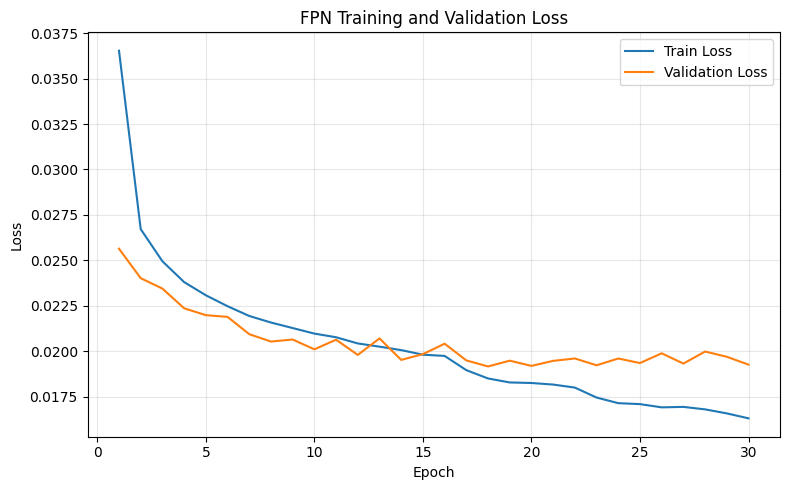

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/loss_curve.png


In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FPN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_CURVE_PATH = (
    RESULTS_DIR /
    "loss_curve.png"
)

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_CURVE_PATH)


# STEP 32 — Plot Dice Curves

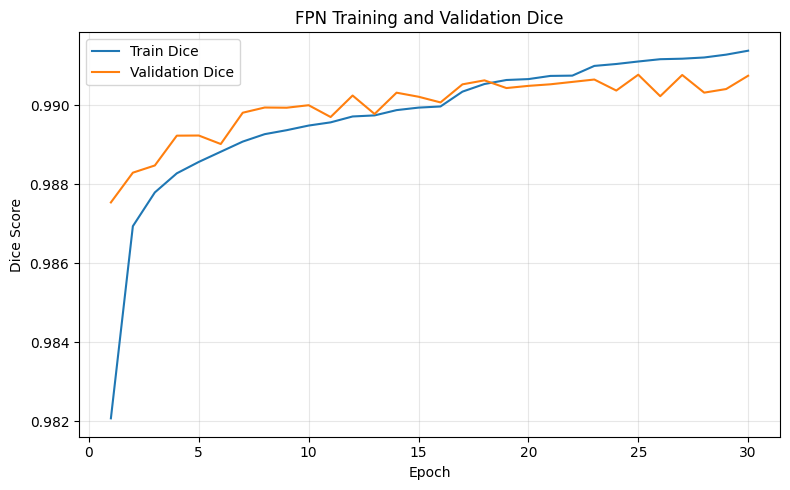

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/dice_curve.png


In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_dice"],
    label="Train Dice"
)

plt.plot(
    history_df["epoch"],
    history_df["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("FPN Training and Validation Dice")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

DICE_CURVE_PATH = (
    RESULTS_DIR /
    "dice_curve.png"
)

plt.savefig(
    DICE_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", DICE_CURVE_PATH)


# STEP 33 — Plot IoU Curves

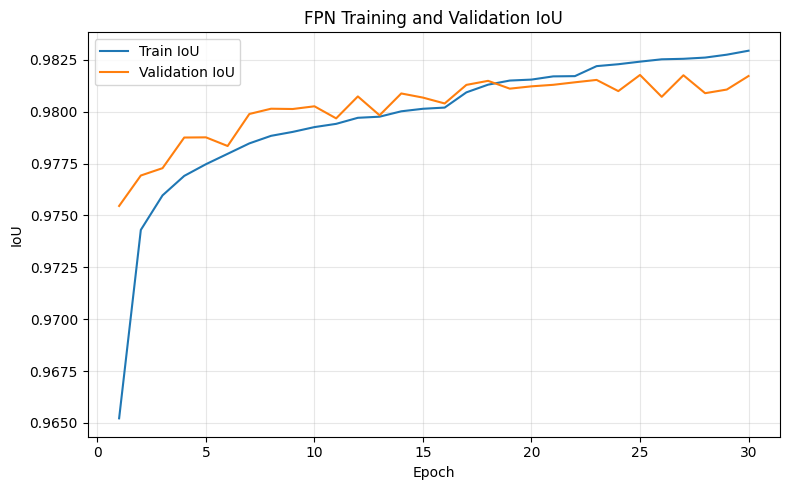

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/iou_curve.png


In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_iou"],
    label="Train IoU"
)

plt.plot(
    history_df["epoch"],
    history_df["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("FPN Training and Validation IoU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

IOU_CURVE_PATH = (
    RESULTS_DIR /
    "iou_curve.png"
)

plt.savefig(
    IOU_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", IOU_CURVE_PATH)


# STEP 34 — Visualize Test Predictions

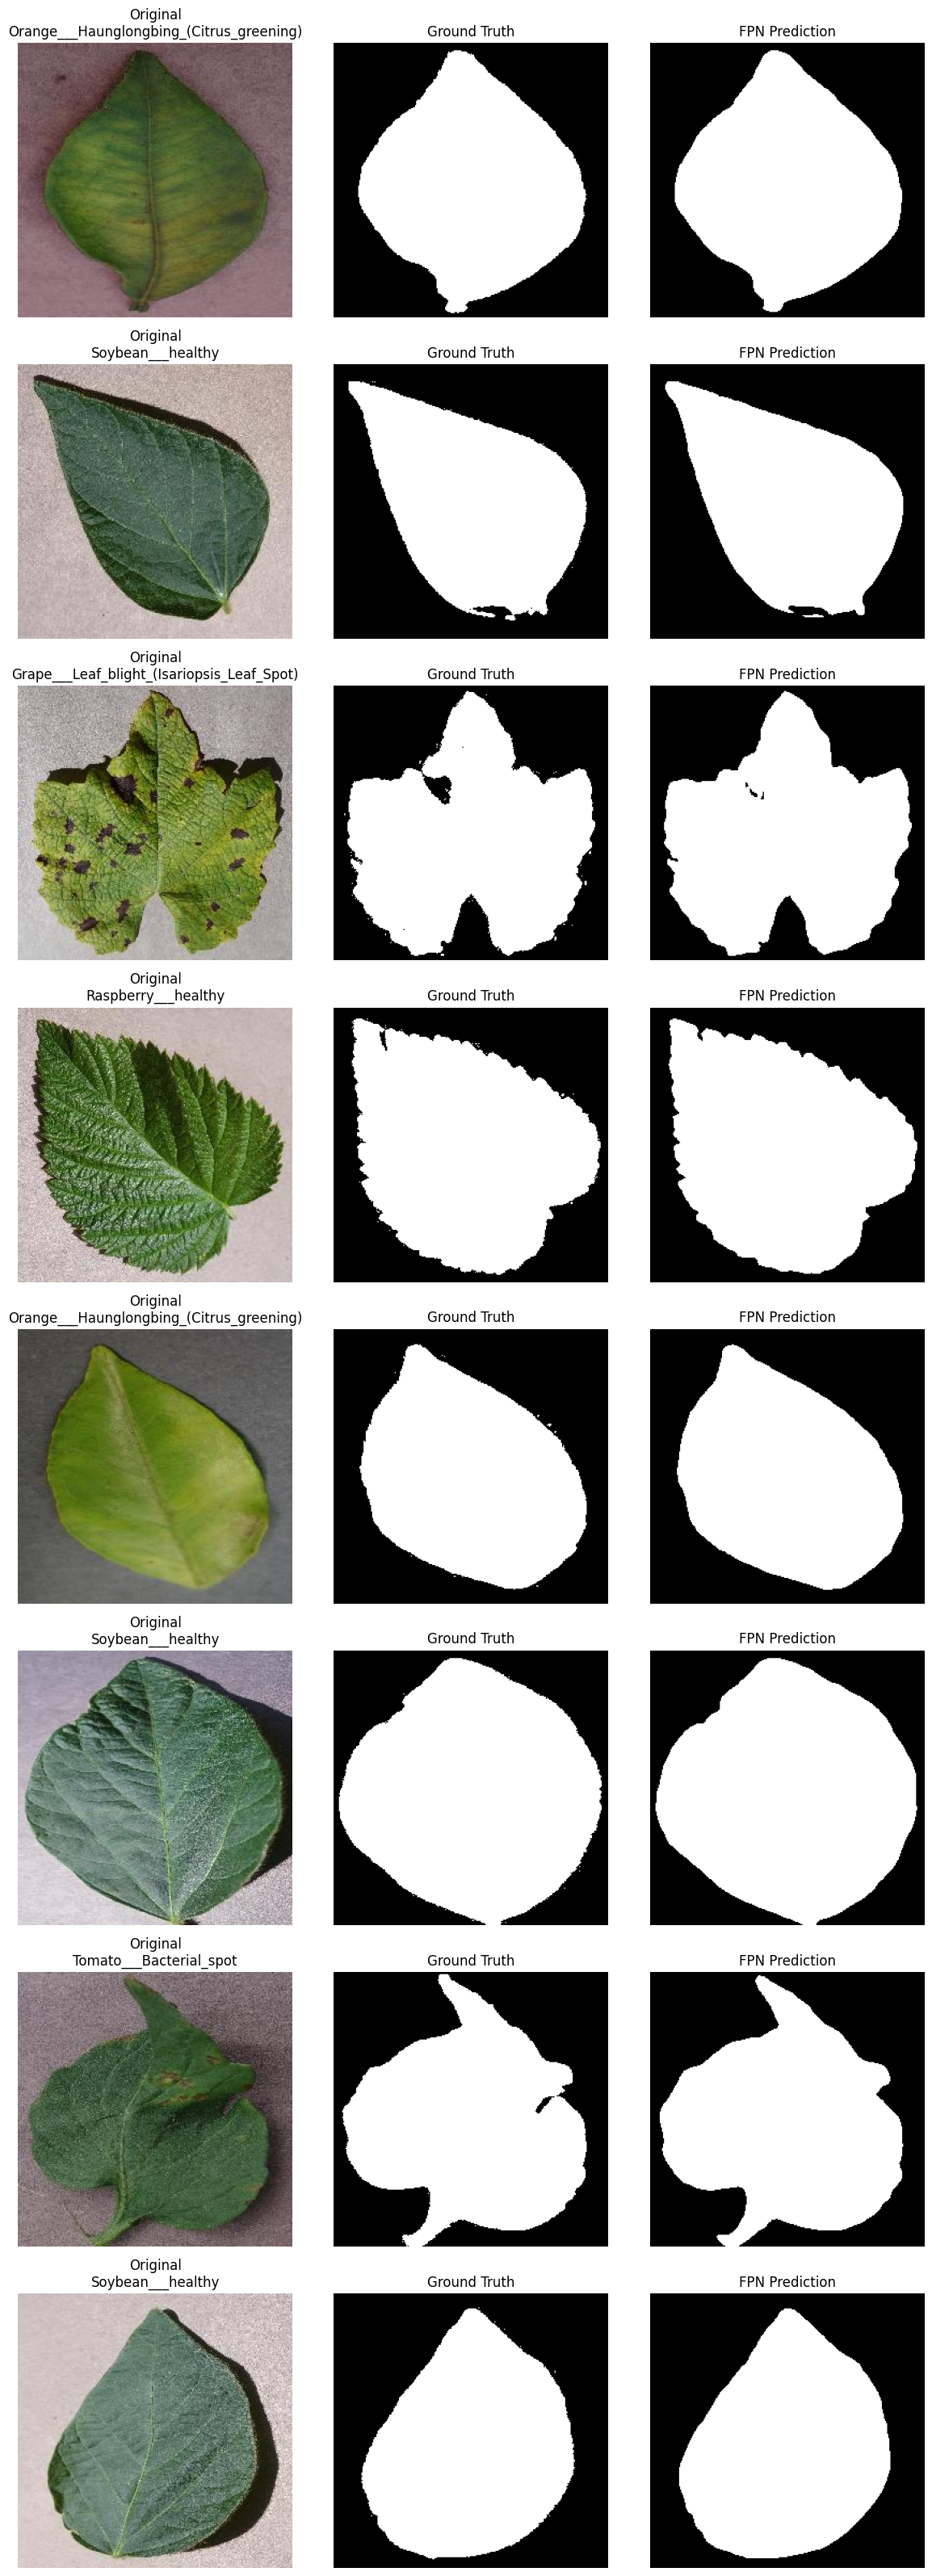

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/predictions/test_predictions.png


In [36]:
random.seed(SEED)

sample_indices = random.sample(
    range(len(test_dataset)),
    8
)

fig, axes = plt.subplots(
    len(sample_indices),
    3,
    figsize=(12, 4 * len(sample_indices))
)

model.eval()

for row_idx, dataset_idx in enumerate(
    sample_indices
):
    sample = test_dataset[
        dataset_idx
    ]

    input_tensor = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.no_grad():

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=(DEVICE.type == "cuda")
        ):
            logits = model(
                input_tensor
            )

        prediction = (
            torch.sigmoid(logits)
            >= 0.5
        ).float()

    predicted_mask = (
        prediction[0, 0]
        .cpu()
        .numpy()
    )

    ground_truth = (
        sample["mask"][0]
        .cpu()
        .numpy()
    )

    original_image = np.array(
        Image.open(
            dataset_root /
            sample["color_rel"]
        ).convert("RGB")
    )

    axes[row_idx, 0].imshow(
        original_image
    )
    axes[row_idx, 0].set_title(
        f"Original\n{sample['class_name']}"
    )
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row_idx, 1].set_title(
        "Ground Truth"
    )
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row_idx, 2].set_title(
        "FPN Prediction"
    )
    axes[row_idx, 2].axis("off")

plt.tight_layout()

PREDICTION_FIGURE_PATH = (
    PREDICTION_DIR /
    "test_predictions.png"
)

plt.savefig(
    PREDICTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", PREDICTION_FIGURE_PATH)


# STEP 35 — Save Individual Prediction Examples

In [37]:
model.eval()

saved_count = 0

for dataset_idx in sample_indices:

    sample = test_dataset[
        dataset_idx
    ]

    image_tensor = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.no_grad():

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=(DEVICE.type == "cuda")
        ):
            logits = model(
                image_tensor
            )

        prediction = (
            torch.sigmoid(logits)
            >= 0.5
        ).float()

    predicted_mask = (
        prediction[0, 0]
        .cpu()
        .numpy()
    )

    ground_truth = (
        sample["mask"][0]
        .cpu()
        .numpy()
    )

    original = np.array(
        Image.open(
            dataset_root /
            sample["color_rel"]
        ).convert("RGB")
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4)
    )

    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title(
        "Ground Truth"
    )
    axes[1].axis("off")

    axes[2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2].set_title(
        "FPN Prediction"
    )
    axes[2].axis("off")

    plt.tight_layout()

    output_path = (
        PREDICTION_DIR /
        f"prediction_{saved_count + 1:02d}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    saved_count += 1

print(
    f"✅ Saved {saved_count} prediction figures."
)


✅ Saved 8 prediction figures.


# STEP 36 — Save Complete FPN Experiment Summary

In [38]:
best_history_row = (
    history_df.loc[
        history_df["val_dice"].idxmax()
    ]
)

experiment_summary = {
    "model": "FPN",
    "encoder": "resnet34",
    "encoder_pretraining": "ImageNet",
    "epochs_completed": int(
        history_df["epoch"].max()
    ),
    "best_epoch": int(
        best_history_row["epoch"]
    ),
    "best_validation_dice": float(
        best_history_row["val_dice"]
    ),
    "best_validation_iou": float(
        best_history_row["val_iou"]
    ),
    "final_train_dice": float(
        history_df.iloc[-1]["train_dice"]
    ),
    "final_validation_dice": float(
        history_df.iloc[-1]["val_dice"]
    ),
    "training_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "training_elapsed_seconds": float(
        training_elapsed_seconds
    ),
    "test_metrics": test_results,
    "checkpoint": str(BEST_MODEL_PATH)
}

SUMMARY_PATH = (
    RESULTS_DIR /
    "experiment_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:
    json.dump(
        experiment_summary,
        f,
        indent=4
    )

print(
    json.dumps(
        experiment_summary,
        indent=2
    )
)


{
  "model": "FPN",
  "encoder": "resnet34",
  "encoder_pretraining": "ImageNet",
  "epochs_completed": 30,
  "best_epoch": 25,
  "best_validation_dice": 0.9907762524952372,
  "best_validation_iou": 0.981766796076154,
  "final_train_dice": 0.9913838064954072,
  "final_validation_dice": 0.9907502851572382,
  "training_samples": 42371,
  "validation_samples": 5300,
  "test_samples": 5298,
  "training_elapsed_seconds": 7070.346355676651,
  "test_metrics": {
    "test_loss": 0.019443246929369454,
    "dice": 0.9908439545071074,
    "iou": 0.9818540541202017,
    "precision": 0.9908031122867805,
    "recall": 0.9908848000947141,
    "specificity": 0.9920126557244912,
    "pixel_accuracy": 0.9914884441256208,
    "tp_pixels": 159907254,
    "fp_pixels": 1484300,
    "fn_pixels": 1470995,
    "tn_pixels": 184347179,
    "threshold": 0.5
  },
  "checkpoint": "/content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/checkpoints/best_fpn.pth"
}


# STEP 37 — Verify Saved FPN Files

In [39]:
important_files = [
    FPN_CONFIG_PATH,
    BEST_MODEL_PATH,
    LAST_MODEL_PATH,
    HISTORY_PATH,
    TEST_METRICS_PATH,
    TEST_METRICS_CSV,
    LOSS_CURVE_PATH,
    DICE_CURVE_PATH,
    IOU_CURVE_PATH,
    PREDICTION_FIGURE_PATH,
    SUMMARY_PATH
]

print("FPN experiment files:")
print("-" * 60)

all_ok = True

for file_path in important_files:

    exists = Path(file_path).exists()

    print(
        "✅" if exists else "❌",
        file_path
    )

    all_ok = (
        all_ok
        and
        exists
    )

assert all_ok, (
    "One or more expected experiment files are missing."
)

print("\n✅ All important FPN files verified.")


FPN experiment files:
------------------------------------------------------------
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/fpn_config.json
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/checkpoints/best_fpn.pth
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/checkpoints/last_fpn.pth
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/training_history.csv
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/test_metrics.json
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/loss_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/dice_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/results/iou_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/FPN/predictions/test_predictions.png
